In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import random
from rf_learning_dataset import RFLearningDataset
import numpy as np
import pandas as pd
from pathlib import Path
class TinyResidualRFNet(nn.Module):
    """
    Minimal sanity-check network.

    Input:
        x        [B,1536,16,8,8]
        baseline [B,2,16,8,8]

    Output:
        pred     [B,2,16,8,8]

    The network predicts a residual correction added to baseline.
    """

    def __init__(self, in_channels=1536, hidden=64, out_channels=2):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv3d(in_channels, hidden, kernel_size=1, padding=0),
            nn.InstanceNorm3d(hidden, affine=True),
            nn.LeakyReLU(0.1, inplace=True),

            nn.Conv3d(hidden, hidden, kernel_size=3, padding=1),
            nn.InstanceNorm3d(hidden, affine=True),
            nn.LeakyReLU(0.1, inplace=True),

            nn.Conv3d(hidden, 32, kernel_size=3, padding=1),
            nn.InstanceNorm3d(32, affine=True),
            nn.LeakyReLU(0.1, inplace=True),

            nn.Conv3d(32, out_channels, kernel_size=1, padding=0),
        )

        # Start close to baseline: final residual initially near zero.
        last = self.net[-1]
        nn.init.zeros_(last.weight)
        nn.init.zeros_(last.bias)

    def forward(self, x, baseline):
        residual = self.net(x)
        pred = baseline + residual
        return pred

@torch.no_grad()
def evaluate_normalized(model, loader, device):
    model.eval()

    total_loss = 0.0
    total_l1 = 0.0
    total_abs = 0.0
    total_base_l1 = 0.0
    total_base_abs = 0.0
    n_batches = 0

    for batch in loader:
        x = batch["input"].to(device, non_blocking=True)
        y = batch["label"].to(device, non_blocking=True)
        b = batch["baseline"].to(device, non_blocking=True)

        pred = model(x, b)

        loss, loss_l1, loss_abs = compute_loss(pred, y)

        base_l1 = F.l1_loss(b, y)
        base_abs = F.l1_loss(complex_abs_2ch(b), complex_abs_2ch(y))

        total_loss += loss.item()
        total_l1 += loss_l1.item()
        total_abs += loss_abs.item()
        total_base_l1 += base_l1.item()
        total_base_abs += base_abs.item()
        n_batches += 1

    total_loss /= max(n_batches, 1)
    total_l1 /= max(n_batches, 1)
    total_abs /= max(n_batches, 1)
    total_base_l1 /= max(n_batches, 1)
    total_base_abs /= max(n_batches, 1)

    improvement = 1.0 - total_l1 / (total_base_l1 + 1e-12)

    return {
        "loss": total_loss,
        "l1": total_l1,
        "abs": total_abs,
        "baseline_l1": total_base_l1,
        "baseline_abs": total_base_abs,
        "improvement": improvement,
    }



def seed_everything(seed=20260522):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
def complex_abs_2ch(x):
    return torch.sqrt(x[:, 0:1] ** 2 + x[:, 1:2] ** 2 + 1e-8)


def compute_loss(pred, label):
    loss_l1 = F.l1_loss(pred, label)

    pred_abs = complex_abs_2ch(pred)
    label_abs = complex_abs_2ch(label)
    loss_abs = F.l1_loss(pred_abs, label_abs)

    loss = loss_l1 + 0.1 * loss_abs
    return loss, loss_l1, loss_abs

def complex_abs_2ch(x):
    """
    x: [B,2,Z,X,Y], real/imag
    return: [B,1,Z,X,Y]
    """
    return torch.sqrt(x[:, 0:1] ** 2 + x[:, 1:2] ** 2 + 1e-8)

def train_tiny_full_jupyter(
    model,
    train_loader,
    val_loader,
    device,
    ckpt_dir,
    num_epochs=100,
    lr=1e-3,
    weight_decay=1e-5,
    print_every=5,
):
    ckpt_dir = Path(ckpt_dir)
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=num_epochs,
        eta_min=1e-5,
    )

    best_val_l1 = float("inf")
    best_epoch = -1
    history = []

    init_val = evaluate_normalized(model, val_loader, device)

    print("\nInitial validation:")
    print(
        f"val_L1={init_val['l1']:.6e} | "
        f"baseline_L1={init_val['baseline_l1']:.6e} | "
        f"improvement={init_val['improvement']*100:.2f}%"
    )

    for epoch in range(1, num_epochs + 1):
        model.train()

        train_loss = 0.0
        train_l1 = 0.0
        train_abs = 0.0
        train_base = 0.0
        n_batches = 0

        for batch in train_loader:
            x = batch["input"].to(device, non_blocking=True)
            y = batch["label"].to(device, non_blocking=True)
            b = batch["baseline"].to(device, non_blocking=True)

            pred = model(x, b)

            loss, loss_l1, loss_abs = compute_loss(pred, y)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            with torch.no_grad():
                base_l1 = F.l1_loss(b, y)

            train_loss += loss.item()
            train_l1 += loss_l1.item()
            train_abs += loss_abs.item()
            train_base += base_l1.item()
            n_batches += 1

        scheduler.step()

        train_loss /= max(n_batches, 1)
        train_l1 /= max(n_batches, 1)
        train_abs /= max(n_batches, 1)
        train_base /= max(n_batches, 1)

        train_impr = 1.0 - train_l1 / (train_base + 1e-12)

        val_metrics = evaluate_normalized(model, val_loader, device)

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_l1": train_l1,
            "train_abs": train_abs,
            "train_base": train_base,
            "train_impr": train_impr,
            "val_l1": val_metrics["l1"],
            "val_abs": val_metrics["abs"],
            "val_base": val_metrics["baseline_l1"],
            "val_impr": val_metrics["improvement"],
            "lr": scheduler.get_last_lr()[0],
        }

        history.append(row)

        if val_metrics["l1"] < best_val_l1:
            best_val_l1 = val_metrics["l1"]
            best_epoch = epoch

            best_ckpt = {
                "epoch": epoch,
                "model": model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "best_val_l1": best_val_l1,
                "history": history,
                "experiment_name": EXPERIMENT_NAME,
            }

            torch.save(best_ckpt, ckpt_dir / "best_tiny_residual_full.pth")
            torch.save(model.state_dict(), ckpt_dir / "best_tiny_residual_full_state_dict.pth")

        if epoch == 1 or epoch % print_every == 0:
            print(
                f"Epoch {epoch:04d} | "
                f"train_L1={train_l1:.6e} | "
                f"train_base={train_base:.6e} | "
                f"train_impr={train_impr*100:6.2f}% | "
                f"val_L1={val_metrics['l1']:.6e} | "
                f"val_base={val_metrics['baseline_l1']:.6e} | "
                f"val_impr={val_metrics['improvement']*100:6.2f}% | "
                f"lr={scheduler.get_last_lr()[0]:.2e}"
            )

    torch.save(model.state_dict(), ckpt_dir / "final_tiny_residual_full_state_dict.pth")

    history_df = pd.DataFrame(history)
    history_df.to_csv(ckpt_dir / "training_history.csv", index=False)

    print("\nTraining finished.")
    print(f"Best val L1 = {best_val_l1:.6e} at epoch {best_epoch}")
    print(f"Best checkpoint saved to: {ckpt_dir / 'best_tiny_residual_full.pth'}")
    print(f"History saved to: {ckpt_dir / 'training_history.csv'}")

    return history_df

root_dir = Path("/home/liujia/RF_Image/Data")

train_root = root_dir / "train"
val_root   = root_dir / "val"
test_root  = root_dir / "test"

train_set = RFLearningDataset(
    root_dir=train_root,
    sample_group="/sample_000001",
    normalize=True,
)

val_set = RFLearningDataset(
    root_dir=val_root,
    sample_group="/sample_000001",
    normalize=True,
)

test_set = RFLearningDataset(
    root_dir=test_root,
    sample_group="/sample_000001",
    normalize=True,
)

train_loader = DataLoader(
    train_set,
    batch_size=4,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)

val_loader = DataLoader(
    val_set,
    batch_size=4,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

test_loader = DataLoader(
    test_set,
    batch_size=4,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

print("Train samples:", len(train_set))
print("Val samples  :", len(val_set))
print("Test samples :", len(test_set))

batch = next(iter(train_loader))
print("input   :", batch["input"].shape)
print("label   :", batch["label"].shape)
print("baseline:", batch["baseline"].shape)

Train samples: 1400
Val samples  : 300
Test samples : 300
input   : torch.Size([4, 1536, 16, 8, 8])
label   : torch.Size([4, 2, 16, 8, 8])
baseline: torch.Size([4, 2, 16, 8, 8])


In [8]:
PROJECT_ROOT = Path("/home/liujia/RF_Image")

DATA_ROOT = PROJECT_ROOT / "Data"
CHECKPOINT_ROOT = PROJECT_ROOT / "checkpoint"
TEST_METRICS_ROOT = PROJECT_ROOT / "test_metrics"
VIS_ROOT = PROJECT_ROOT / "vis_best_model"

EXPERIMENT_NAME = "tiny_residual_full_2000"

CKPT_DIR = CHECKPOINT_ROOT / EXPERIMENT_NAME
METRIC_DIR = TEST_METRICS_ROOT / EXPERIMENT_NAME
VIS_DIR = VIS_ROOT / EXPERIMENT_NAME

CKPT_DIR.mkdir(parents=True, exist_ok=True)
METRIC_DIR.mkdir(parents=True, exist_ok=True)
VIS_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_ROOT:", DATA_ROOT)
print("CKPT_DIR :", CKPT_DIR)
print("METRIC_DIR:", METRIC_DIR)
print("VIS_DIR:", VIS_DIR)

train_root = DATA_ROOT / "train"
val_root   = DATA_ROOT / "val"
test_root  = DATA_ROOT / "test"

train_set = RFLearningDataset(
    root_dir=train_root,
    sample_group="/sample_000001",
    normalize=True,
)

val_set = RFLearningDataset(
    root_dir=val_root,
    sample_group="/sample_000001",
    normalize=True,
)

test_set = RFLearningDataset(
    root_dir=test_root,
    sample_group="/sample_000001",
    normalize=True,
)

batch_size = 12

train_loader = DataLoader(
    train_set,
    batch_size=batch_size,
    shuffle=True,
    num_workers=8,
    pin_memory=True,
)

val_loader = DataLoader(
    val_set,
    batch_size=batch_size,
    shuffle=False,
    num_workers=8,
    pin_memory=True,
)

test_loader = DataLoader(
    test_set,
    batch_size=batch_size,
    shuffle=False,
    num_workers=8,
    pin_memory=True,
)

print("Train samples:", len(train_set))
print("Val samples  :", len(val_set))
print("Test samples :", len(test_set))

batch = next(iter(train_loader))
print("\nOne batch:")
print("input   :", batch["input"].shape)
print("label   :", batch["label"].shape)
print("baseline:", batch["baseline"].shape)

DATA_ROOT: /home/liujia/RF_Image/Data
CKPT_DIR : /home/liujia/RF_Image/checkpoint/tiny_residual_full_2000
METRIC_DIR: /home/liujia/RF_Image/test_metrics/tiny_residual_full_2000
VIS_DIR: /home/liujia/RF_Image/vis_best_model/tiny_residual_full_2000
Train samples: 1400
Val samples  : 300
Test samples : 300



One batch:
input   : torch.Size([12, 1536, 16, 8, 8])
label   : torch.Size([12, 2, 16, 8, 8])
baseline: torch.Size([12, 2, 16, 8, 8])


In [9]:
seed_everything(20260522)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

tiny_full_model = TinyResidualRFNet(
    in_channels=1536,
    hidden=64,
    out_channels=2,
).to(device)

n_params = sum(p.numel() for p in tiny_full_model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params/1e6:.3f} M")

history_tiny_full = train_tiny_full_jupyter(
    model=tiny_full_model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    ckpt_dir=CKPT_DIR,
    num_epochs=100,
    lr=1e-3,
    weight_decay=1e-5,
    print_every=5,
)

Device: cuda
Trainable parameters: 0.265 M

Initial validation:
val_L1=6.481854e-01 | baseline_L1=6.481854e-01 | improvement=0.00%
Epoch 0001 | train_L1=4.402798e-01 | train_base=6.471986e-01 | train_impr= 31.97% | val_L1=3.737251e-01 | val_base=6.481854e-01 | val_impr= 42.34% | lr=1.00e-03
Epoch 0005 | train_L1=3.403721e-01 | train_base=6.474597e-01 | train_impr= 47.43% | val_L1=3.391171e-01 | val_base=6.481854e-01 | val_impr= 47.68% | lr=9.94e-04
Epoch 0010 | train_L1=2.872823e-01 | train_base=6.470939e-01 | train_impr= 55.60% | val_L1=3.320698e-01 | val_base=6.481854e-01 | val_impr= 48.77% | lr=9.76e-04
Epoch 0015 | train_L1=2.536742e-01 | train_base=6.471002e-01 | train_impr= 60.80% | val_L1=3.318895e-01 | val_base=6.481854e-01 | val_impr= 48.80% | lr=9.46e-04
Epoch 0020 | train_L1=2.389733e-01 | train_base=6.471206e-01 | train_impr= 63.07% | val_L1=3.307752e-01 | val_base=6.481854e-01 | val_impr= 48.97% | lr=9.05e-04
Epoch 0025 | train_L1=2.289200e-01 | train_base=6.471144e-01 | t

In [12]:

@torch.no_grad()
def evaluate_full_test_set(
    model,
    dataset,
    device,
    batch_size=4,
    save_csv_path=None,
):
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=True,
    )

    model.eval()

    rows = []

    for batch in loader:
        x = batch["input"].to(device, non_blocking=True)
        y = batch["label"].to(device, non_blocking=True)
        b = batch["baseline"].to(device, non_blocking=True)

        scale = batch["scale"].to(device)
        if scale.ndim == 1:
            scale = scale.view(-1, 1, 1, 1, 1)

        pred = model(x, b)

        # Denormalize if dataset used normalize=True.
        pred_raw = pred * scale
        y_raw = y * scale
        b_raw = b * scale

        # Per-sample complex L1.
        pred_l1 = torch.mean(torch.abs(pred_raw - y_raw), dim=(1, 2, 3, 4))
        base_l1 = torch.mean(torch.abs(b_raw - y_raw), dim=(1, 2, 3, 4))

        # Per-sample envelope L1.
        pred_abs = complex_abs_2ch(pred_raw)
        y_abs = complex_abs_2ch(y_raw)
        b_abs = complex_abs_2ch(b_raw)

        pred_abs_l1 = torch.mean(torch.abs(pred_abs - y_abs), dim=(1, 2, 3, 4))
        base_abs_l1 = torch.mean(torch.abs(b_abs - y_abs), dim=(1, 2, 3, 4))

        paths = batch["path"]

        for i, path in enumerate(paths):
            pl1 = float(pred_l1[i].cpu())
            bl1 = float(base_l1[i].cpu())
            pa1 = float(pred_abs_l1[i].cpu())
            ba1 = float(base_abs_l1[i].cpu())

            rows.append({
                "path": path,
                "category": infer_category_from_path(path),

                "pred_complex_l1": pl1,
                "base_complex_l1": bl1,
                "complex_improvement": 1.0 - pl1 / (bl1 + 1e-12),
                "complex_better": pl1 < bl1,

                "pred_abs_l1": pa1,
                "base_abs_l1": ba1,
                "abs_improvement": 1.0 - pa1 / (ba1 + 1e-12),
                "abs_better": pa1 < ba1,
            })

    df = pd.DataFrame(rows)

    if save_csv_path is not None:
        save_csv_path = Path(save_csv_path)
        save_csv_path.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(save_csv_path, index=False)
        print(f"Saved per-sample metrics to: {save_csv_path}")

    return df


def summarize_test_metrics(df):
    overall = {
        "n": len(df),

        "complex_pred_mean": df["pred_complex_l1"].mean(),
        "complex_base_mean": df["base_complex_l1"].mean(),
        "complex_improvement_mean": df["complex_improvement"].mean(),
        "complex_better_rate": df["complex_better"].mean(),

        "abs_pred_mean": df["pred_abs_l1"].mean(),
        "abs_base_mean": df["base_abs_l1"].mean(),
        "abs_improvement_mean": df["abs_improvement"].mean(),
        "abs_better_rate": df["abs_better"].mean(),
    }

    print("\n================ Overall test summary ================")
    print(f"Samples: {overall['n']}")

    print("\n[Complex L1]")
    print(f"pred mean       : {overall['complex_pred_mean']:.4e}")
    print(f"baseline mean   : {overall['complex_base_mean']:.4e}")
    print(f"mean improvement: {overall['complex_improvement_mean']*100:.2f}%")
    print(f"better rate     : {overall['complex_better_rate']*100:.2f}%")

    print("\n[Envelope abs L1]")
    print(f"pred mean       : {overall['abs_pred_mean']:.4e}")
    print(f"baseline mean   : {overall['abs_base_mean']:.4e}")
    print(f"mean improvement: {overall['abs_improvement_mean']*100:.2f}%")
    print(f"better rate     : {overall['abs_better_rate']*100:.2f}%")

    print("\n================ Per-category summary ================")
    cat_summary = df.groupby("category").agg(
        n=("path", "count"),

        complex_pred_mean=("pred_complex_l1", "mean"),
        complex_base_mean=("base_complex_l1", "mean"),
        complex_improvement_mean=("complex_improvement", "mean"),
        complex_better_rate=("complex_better", "mean"),

        abs_pred_mean=("pred_abs_l1", "mean"),
        abs_base_mean=("base_abs_l1", "mean"),
        abs_improvement_mean=("abs_improvement", "mean"),
        abs_better_rate=("abs_better", "mean"),
    )

    display(cat_summary)

    return overall, cat_summary

In [14]:
ckpt_path = CKPT_DIR / "best_tiny_residual_full.pth"
def infer_category_from_path(path):
    p = str(path).lower()
    for cat in ["carotid", "muscle", "phantom", "simu_point"]:
        if cat in p:
            return cat
    return "unknown"
best_model = TinyResidualRFNet(
    in_channels=1536,
    hidden=64,
    out_channels=2,
).to(device)

ckpt = torch.load(ckpt_path, map_location=device)
best_model.load_state_dict(ckpt["model"])

print(f"Loaded best model, epoch = {ckpt['epoch']}")
print(f"Best val L1 = {ckpt['best_val_l1']}")

df_test_full = evaluate_full_test_set(
    model=best_model,
    dataset=test_set,
    device=device,
    batch_size=4,
    save_csv_path=METRIC_DIR / "test_per_sample_metrics.csv",
)

overall_full, cat_summary_full = summarize_test_metrics(df_test_full)

cat_summary_full.to_csv(METRIC_DIR / "test_per_category_summary.csv")
pd.DataFrame([overall_full]).to_csv(METRIC_DIR / "test_overall_summary.csv", index=False)

print("Saved test metrics to:", METRIC_DIR)

Loaded best model, epoch = 25
Best val L1 = 0.32657902359962465
Saved per-sample metrics to: /home/liujia/RF_Image/test_metrics/tiny_residual_full_2000/test_per_sample_metrics.csv

================ Overall test summary ================
Samples: 300

[Complex L1]
pred mean       : 1.1292e+04
baseline mean   : 7.8817e+03
mean improvement: 15.49%
better rate     : 90.67%

[Envelope abs L1]
pred mean       : 1.3943e+04
baseline mean   : 8.8872e+03
mean improvement: 14.22%
better rate     : 91.67%

================ Per-category summary ================


,n,complex_pred_mean,complex_base_mean,complex_improvement_mean,complex_better_rate,abs_pred_mean,abs_base_mean,abs_improvement_mean,abs_better_rate
category,,,,,,,,,
carotid,75,6525.004829,8853.747764,0.360973,0.906667,5560.400143,8805.461160,0.415391,0.906667
muscle,75,3828.348853,7649.877194,0.473620,0.973333,3294.551147,8249.515830,0.564320,1.000000
phantom,75,1440.041169,2498.391660,0.467711,0.986667,1238.180921,2565.977287,0.514481,1.000000
simu_point,75,33372.628722,12524.614394,-0.682683,0.760000,45680.711242,15927.738435,-0.925439,0.760000


Saved test metrics to: /home/liujia/RF_Image/test_metrics/tiny_residual_full_2000


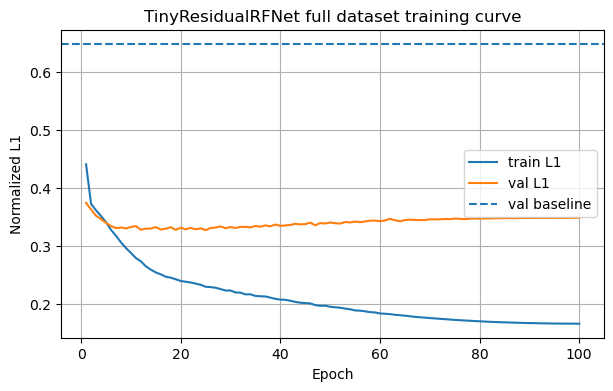

epoch         25.000000
train_loss     0.251342
train_l1       0.228920
train_abs      0.224218
train_base     0.647114
train_impr     0.646245
val_l1         0.326579
val_abs        0.305649
val_base       0.648185
val_impr       0.496164
lr             0.000855
Name: 24, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 4))
plt.plot(history_tiny_full["epoch"], history_tiny_full["train_l1"], label="train L1")
plt.plot(history_tiny_full["epoch"], history_tiny_full["val_l1"], label="val L1")
plt.axhline(history_tiny_full["val_base"].iloc[0], linestyle="--", label="val baseline")
plt.xlabel("Epoch")
plt.ylabel("Normalized L1")
plt.title("TinyResidualRFNet full dataset training curve")
plt.legend()
plt.grid(True)
plt.show()

best_row = history_tiny_full.loc[history_tiny_full["val_l1"].idxmin()]
print(best_row)

In [17]:
worse_complex = df_test_full[df_test_full["complex_better"] == False].copy()
worse_abs = df_test_full[df_test_full["abs_better"] == False].copy()

print("Complex worse samples:", len(worse_complex))
display(worse_complex.sort_values("complex_improvement").head(20))

print("Abs worse samples:", len(worse_abs))
display(worse_abs.sort_values("abs_improvement").head(20))

Complex worse samples: 28


,path,category,pred_complex_l1,base_complex_l1,complex_improvement,complex_better,pred_abs_l1,base_abs_l1,abs_improvement,abs_better
285,/home/liujia/RF_Image/Data/test/simu_point/RF0...,simu_point,391308.062500,15861.066406,-23.670981,False,544983.500000,15813.549805,-33.463072,False
252,/home/liujia/RF_Image/Data/test/simu_point/RF0...,simu_point,649686.437500,38065.179688,-16.067736,False,990678.437500,44848.980469,-21.089208,False
243,/home/liujia/RF_Image/Data/test/simu_point/RF0...,simu_point,526162.875000,32559.037109,-15.160271,False,775692.500000,35347.675781,-20.944654,False
286,/home/liujia/RF_Image/Data/test/simu_point/RF0...,simu_point,73123.906250,9517.699219,-6.682939,False,102775.187500,11718.100586,-7.770635,False
299,/home/liujia/RF_Image/Data/test/simu_point/RF0...,simu_point,189600.281250,26982.546875,-6.026775,False,243492.031250,28982.738281,-7.401278,False
295,/home/liujia/RF_Image/Data/test/simu_point/RF0...,simu_point,26909.062500,7312.584961,-2.679829,False,34389.488281,9417.464844,-2.651672,False
261,/home/liujia/RF_Image/Data/test/simu_point/RF0...,simu_point,61655.128906,17814.769531,-2.460900,False,77372.679688,21632.449219,-2.576695,False
232,/home/liujia/RF_Image/Data/test/simu_point/RF0...,simu_point,82748.343750,27249.896484,-2.036648,False,113259.656250,35463.046875,-2.193737,False
31,/home/liujia/RF_Image/Data/test/carotid/RF0004...,carotid,50197.667969,16654.449219,-2.014070,False,53012.261719,15645.277344,-2.388387,False
248,/home/liujia/RF_Image/Data/test/simu_point/RF0...,simu_point,11829.884766,3942.993652,-2.000229,False,14823.585938,3497.483398,-3.238358,False


Abs worse samples: 25


,path,category,pred_complex_l1,base_complex_l1,complex_improvement,complex_better,pred_abs_l1,base_abs_l1,abs_improvement,abs_better
285,/home/liujia/RF_Image/Data/test/simu_point/RF0...,simu_point,391308.062500,15861.066406,-23.670981,False,544983.500000,15813.549805,-33.463072,False
252,/home/liujia/RF_Image/Data/test/simu_point/RF0...,simu_point,649686.437500,38065.179688,-16.067736,False,990678.437500,44848.980469,-21.089208,False
243,/home/liujia/RF_Image/Data/test/simu_point/RF0...,simu_point,526162.875000,32559.037109,-15.160271,False,775692.500000,35347.675781,-20.944654,False
286,/home/liujia/RF_Image/Data/test/simu_point/RF0...,simu_point,73123.906250,9517.699219,-6.682939,False,102775.187500,11718.100586,-7.770635,False
299,/home/liujia/RF_Image/Data/test/simu_point/RF0...,simu_point,189600.281250,26982.546875,-6.026775,False,243492.031250,28982.738281,-7.401278,False
248,/home/liujia/RF_Image/Data/test/simu_point/RF0...,simu_point,11829.884766,3942.993652,-2.000229,False,14823.585938,3497.483398,-3.238358,False
295,/home/liujia/RF_Image/Data/test/simu_point/RF0...,simu_point,26909.062500,7312.584961,-2.679829,False,34389.488281,9417.464844,-2.651672,False
261,/home/liujia/RF_Image/Data/test/simu_point/RF0...,simu_point,61655.128906,17814.769531,-2.460900,False,77372.679688,21632.449219,-2.576695,False
31,/home/liujia/RF_Image/Data/test/carotid/RF0004...,carotid,50197.667969,16654.449219,-2.014070,False,53012.261719,15645.277344,-2.388387,False
232,/home/liujia/RF_Image/Data/test/simu_point/RF0...,simu_point,82748.343750,27249.896484,-2.036648,False,113259.656250,35463.046875,-2.193737,False


In [18]:
import matplotlib.pyplot as plt


def to_numpy_volume(x):
    if torch.is_tensor(x):
        x = x.detach().cpu().numpy()
    return x


def complex_abs_numpy(x_2ch):
    """
    x_2ch: [2,Z,X,Y]
    """
    return np.sqrt(x_2ch[0] ** 2 + x_2ch[1] ** 2 + 1e-12)


def volume_to_db(img, ref=None, db_min=-60):
    if ref is None:
        ref = np.max(img)
    if ref <= 0:
        ref = 1.0

    out = 20 * np.log10(img / ref + 1e-12)
    out[out < db_min] = db_min
    out[out > 0] = 0
    return out


@torch.no_grad()
def visualize_best_model_samples(
    model,
    dataset,
    device,
    save_dir,
    indices=None,
    n_per_category=3,
    y_slice=None,
    db_min=-60,
):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    model.eval()

    # If indices are not provided, choose n_per_category samples per category.
    if indices is None:
        cat_to_indices = {}

        for i, path in enumerate(dataset.files):
            cat = infer_category_from_path(str(path))
            cat_to_indices.setdefault(cat, []).append(i)

        indices = []
        for cat, idxs in cat_to_indices.items():
            indices.extend(idxs[:n_per_category])

    print("Selected indices:", indices)

    saved_paths = []

    for count, idx in enumerate(indices, start=1):
        sample = dataset[idx]

        x = sample["input"].unsqueeze(0).to(device)
        y = sample["label"].unsqueeze(0).to(device)
        b = sample["baseline"].unsqueeze(0).to(device)

        scale = sample["scale"]
        if torch.is_tensor(scale):
            scale = scale.to(device).view(1, 1, 1, 1, 1)
        else:
            scale = torch.tensor(scale, device=device).view(1, 1, 1, 1, 1)

        pred = model(x, b)

        pred = (pred * scale)[0].detach().cpu()
        label = (y * scale)[0].detach().cpu()
        base = (b * scale)[0].detach().cpu()

        pred_np = pred.numpy()
        label_np = label.numpy()
        base_np = base.numpy()

        pred_abs = complex_abs_numpy(pred_np)
        label_abs = complex_abs_numpy(label_np)
        base_abs = complex_abs_numpy(base_np)

        err_pred = np.abs(pred_abs - label_abs)
        err_base = np.abs(base_abs - label_abs)

        Z, X, Y = label_abs.shape

        if y_slice is None:
            iy = Y // 2
        else:
            iy = y_slice

        ref = np.max([base_abs.max(), pred_abs.max(), label_abs.max()])

        imgs = [
            volume_to_db(base_abs[:, :, iy], ref=ref, db_min=db_min),
            volume_to_db(pred_abs[:, :, iy], ref=ref, db_min=db_min),
            volume_to_db(label_abs[:, :, iy], ref=ref, db_min=db_min),
            volume_to_db(err_pred[:, :, iy], ref=ref, db_min=db_min),
            volume_to_db(err_base[:, :, iy], ref=ref, db_min=db_min),
        ]

        titles = [
            "3-angle baseline",
            "network prediction",
            "33-angle label",
            "|pred-label|",
            "|baseline-label|",
        ]

        path = Path(sample["path"])
        cat = infer_category_from_path(str(path))
        name = path.stem

        pred_l1 = np.mean(np.abs(pred_np - label_np))
        base_l1 = np.mean(np.abs(base_np - label_np))

        pred_abs_l1 = np.mean(np.abs(pred_abs - label_abs))
        base_abs_l1 = np.mean(np.abs(base_abs - label_abs))

        fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))

        for ax, img, title in zip(axes, imgs, titles):
            im = ax.imshow(img, cmap="gray", vmin=db_min, vmax=0, aspect="auto")
            ax.set_title(title)
            ax.set_xlabel("x index")
            ax.set_ylabel("z index")
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        fig.suptitle(
            f"{cat} | {name} | y-slice={iy}\n"
            f"complex L1 pred/base: {pred_l1:.3e} / {base_l1:.3e} | "
            f"abs L1 pred/base: {pred_abs_l1:.3e} / {base_abs_l1:.3e}",
            fontsize=10,
        )

        fig.tight_layout()

        save_path = save_dir / f"{count:03d}_{cat}_{name}.png"
        fig.savefig(save_path, dpi=200)
        plt.close(fig)

        saved_paths.append(save_path)

        print(f"Saved: {save_path}")
        print(f"  complex L1 pred/base: {pred_l1:.4e} / {base_l1:.4e}")
        print(f"  abs     L1 pred/base: {pred_abs_l1:.4e} / {base_abs_l1:.4e}")

    return saved_paths

In [19]:
saved_vis = visualize_best_model_samples(
    model=best_model,
    dataset=test_set,
    device=device,
    save_dir=VIS_DIR,
    indices=None,
    n_per_category=3,
    y_slice=None,
    db_min=-60,
)

print("Saved visualizations:", len(saved_vis))
print("VIS_DIR:", VIS_DIR)

Selected indices: [0, 1, 2, 75, 76, 77, 150, 151, 152, 225, 226, 227]
Saved: /home/liujia/RF_Image/vis_best_model/tiny_residual_full_2000/001_carotid_RF000486_carotid_test_patch001.png
  complex L1 pred/base: 1.1263e+04 / 1.3601e+04
  abs     L1 pred/base: 6.3250e+03 / 1.2952e+04
Saved: /home/liujia/RF_Image/vis_best_model/tiny_residual_full_2000/002_carotid_RF000486_carotid_test_patch002.png
  complex L1 pred/base: 5.7914e+03 / 1.9757e+04
  abs     L1 pred/base: 5.1428e+03 / 2.3112e+04
Saved: /home/liujia/RF_Image/vis_best_model/tiny_residual_full_2000/003_carotid_RF000486_carotid_test_patch003.png
  complex L1 pred/base: 9.7174e+03 / 8.1858e+03
  abs     L1 pred/base: 8.4423e+03 / 8.0640e+03
Saved: /home/liujia/RF_Image/vis_best_model/tiny_residual_full_2000/004_muscle_RF000386_muscle_test_patch001.png
  complex L1 pred/base: 3.1871e+03 / 5.9643e+03
  abs     L1 pred/base: 3.1355e+03 / 5.8951e+03
Saved: /home/liujia/RF_Image/vis_best_model/tiny_residual_full_2000/005_muscle_RF000386_

In [ ]:
df_nonpoint = df_test_full[df_test_full["category"] != "simu_point"].copy()

overall_nonpoint, cat_summary_nonpoint = summarize_test_metrics(df_nonpoint)

In [ ]:
seed_everything(20260522)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

tiny_full_model = TinyResidualRFNet(
    in_channels=1536,
    hidden=64,
    out_channels=2,
).to(device)

n_params = sum(p.numel() for p in tiny_full_model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params/1e6:.3f} M")

history_tiny_full = train_tiny_full_jupyter(
    model=tiny_full_model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    ckpt_dir=CKPT_DIR,
    num_epochs=100,
    lr=1e-3,
    weight_decay=1e-5,
    print_every=5,
)